# Что меняется между вдохом и выдохом: осмотр данных

Ноутбук существует потому, что три ошибки подряд прошли все автоматические проверки и
были видны только глазами. Он не считает результат — он показывает, можно ли верить
тому, что считает конвейер.

Порядок такой: сначала проверяется, правильно ли поняты оси тома, потом — правильно ли
выделены тело и лёгкое, и только потом смотрится, что изменилось между фазами.

Данные: пары DIR-Lab COPDgene (`iBHCT` / `eBHCT`), единственный набор на диске с полным
торсом и обеими фазами.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

from breathgeom.io.dirlab import load_copdgene
from breathgeom.measure.wall import AIR_HU, Side, WallParams, body_mask, lung_mask

# Каталог с распакованными случаями DIR-Lab: copd1/copd1_iBHCT.img и т.д.
DIRLAB_ROOT = Path("E:/КТ папка/dirlab_copdgene/extracted")
CASE = "copd1"

MP = WallParams()
plt.rcParams["figure.dpi"] = 110

## 1. Загрузка и отчёт об ориентации

Формат DIR-Lab безголовый: ни размеров, ни шага, ни ориентации, ни шкалы интенсивностей.
Всё это либо берётся из опубликованной таблицы, либо восстанавливается из самого
изображения — и тогда обязано быть предъявлено, а не принято на веру.

Ориентация определяется **один раз на человека** по более наполненному скану и
применяется к обеим фазам: две фазы одного человека не могут иметь разную анатомию.

In [2]:
folder = DIRLAB_ROOT / CASE
_, _, orientation = load_copdgene(folder / f"{CASE}_iBHCT.img", CASE)

volumes = {}
for tag in ("iBHCT", "eBHCT"):
    volume, spacing, _ = load_copdgene(
        folder / f"{CASE}_{tag}.img", CASE, orientation=orientation
    )
    volumes[tag] = volume
sx, sy, sz = spacing

print(f"{CASE}: {volumes['iBHCT'].shape}, шаг {sx} x {sy} x {sz} мм")
print()
print(f"позвоночник смещён на {orientation.spine_offset_px:+.0f} px -> "
      f"задняя сторона у больших индексов: {orientation.posterior_is_high_row}")
print(f"асимметрия воздуха {orientation.lung_asymmetry:+.3f} -> "
      f"правая сторона у больших индексов: {orientation.right_is_high_index}")
print(f"каудальный избыток воздуха {orientation.caudal_air_excess:+.3f}, "
      f"резкость диафрагмы {orientation.diaphragm_sharpness_ratio:.2f} -> "
      f"голова у больших индексов: {orientation.superior_is_high_index}")
print(f"признаки головы/ног согласованы: {orientation.sides_agree}")
print(f"пик воздуха восстановлен на {orientation.air_peak_hu:.0f} HU")

copd1: (512, 512, 121), шаг 0.625 x 0.625 x 2.5 мм

позвоночник смещён на +57 px -> задняя сторона у больших индексов: True
асимметрия воздуха -0.028 -> правая сторона у больших индексов: False
каудальный избыток воздуха -0.079, резкость диафрагмы 0.65 -> голова у больших индексов: False
признаки головы/ног согласованы: True
пик воздуха восстановлен на -995 HU


## 2. Проверка осей по анатомии

Это главная проверка ноутбука. Оси не подписаны в файле, и ошибка в них не вызывает
никакого исключения — она просто делает все дальнейшие числа бессмысленными.

Два независимых признака:

- **позвонок** — самая плотная структура, лежит сзади и по средней линии. По
  передне-задней оси его гистограмма обязана быть смещена к одному краю, по
  лево-правой — иметь пик в центре;
- **сердце** смещает левое лёгкое, поэтому по лево-правой оси воздух распределён
  асимметрично, а по передне-задней — примерно симметрично.

Если картина обратная, оси перепутаны.

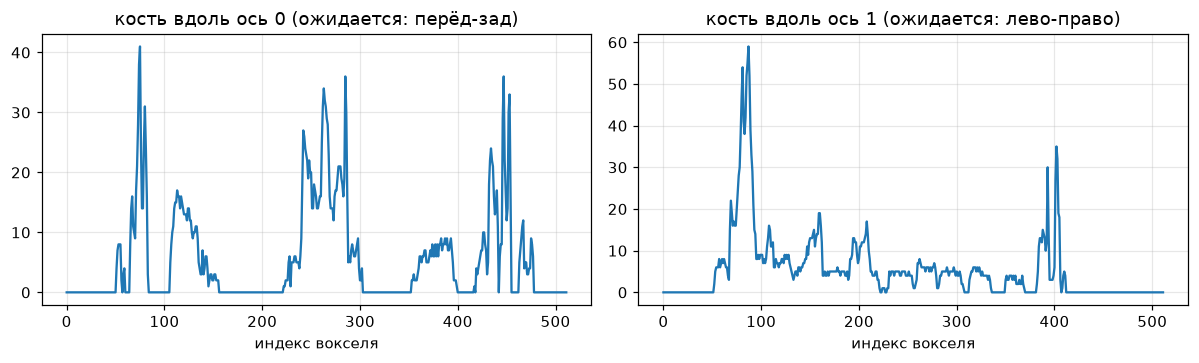

воздух по ось 0: 42382 / 43535, отношение 1.03
воздух по ось 1: 43237 / 42680, отношение 0.99


In [3]:
volume = volumes["iBHCT"]
middle = volume.shape[2] // 2
slice_hu = volume[:, :, middle].astype(np.int32)
body = body_mask(slice_hu, MP)
bone = body & (slice_hu > 300)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, axis, name in ((ax[0], 0, "ось 0 (ожидается: перёд-зад)"),
                      (ax[1], 1, "ось 1 (ожидается: лево-право)")):
    counts = bone.sum(axis=1 - axis)
    a.plot(counts)
    a.set_title(f"кость вдоль {name}")
    a.set_xlabel("индекс вокселя")
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

air = body & (slice_hu < AIR_HU)
rows, columns = np.where(air)
for axis, values, name in ((0, rows, "ось 0"), (1, columns, "ось 1")):
    spanned = np.flatnonzero(body.any(axis=1 - axis))
    midline = 0.5 * (spanned[0] + spanned[-1])
    low = int((values < midline).sum())
    high = int((values >= midline).sum())
    print(f"воздух по {name}: {low} / {high}, отношение {high / max(low, 1):.2f}")

Ожидаемое для корректных осей: по **лево-правой** оси кость даёт узкий пик в центре
(позвонок на средней линии), по **передне-задней** — смещение к одному краю. Воздух
асимметричен по лево-правой оси и симметричен по передне-задней.

## 3. Профили по срезам

Три величины, каждая ловит свой класс ошибок:

- **сечение тела** — меняется ли поза и укладка между фазами;
- **сечение правого лёгкого** — работает ли выделение лёгкого вообще;
- **наружная граница сбоку** — двигается ли кожа.

Скачки сечения лёгкого между соседними срезами анатомически невозможны. Если они есть,
маска выбирает разные объекты, и всё, что построено на ней, недействительно.

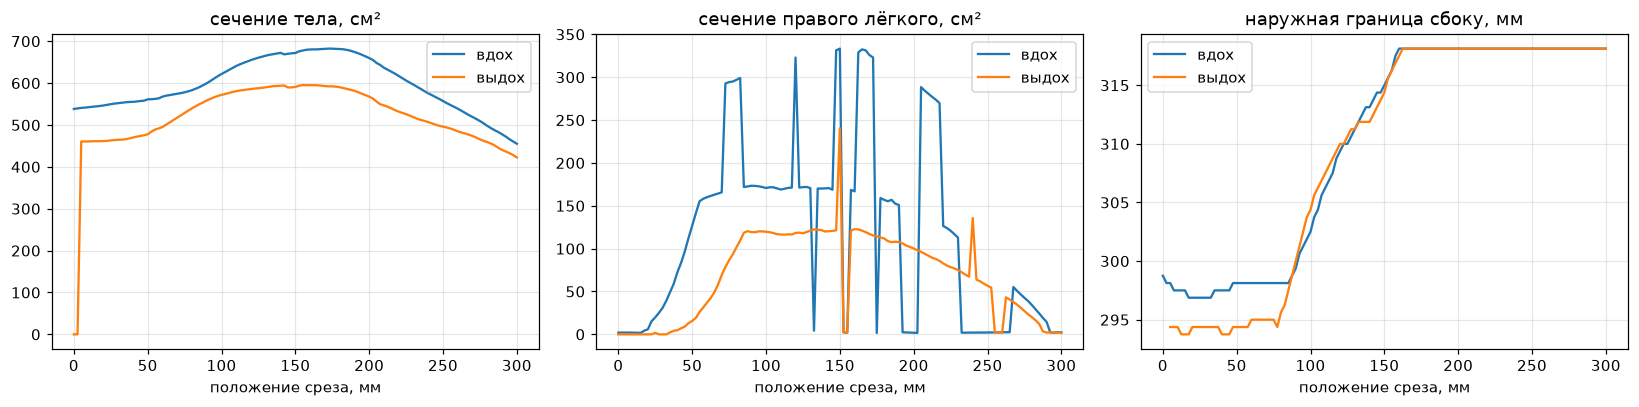

наибольший скачок сечения лёгкого между соседними срезами: вдох 331 см², выдох 238 см²
Скачок в десятки см² означает, что маска переключается между разными объектами.


In [4]:
def profiles(volume):
    body_area, lung_area, lateral = [], [], []
    for index in range(volume.shape[2]):
        current = volume[:, :, index]
        mask = body_mask(current, MP)
        if mask is None:
            body_area.append(0.0)
            lung_area.append(0.0)
            lateral.append(np.nan)
            continue
        body_area.append(float(mask.sum()) * sx * sy / 100.0)
        lung = lung_mask(current, mask, Side.RIGHT, MP)
        lung_area.append(float(lung.sum()) * sx * sy / 100.0 if lung is not None else 0.0)
        occupied = np.where(mask.any(axis=1))[0]
        lateral.append(float(occupied.max()) * sx)
    return map(np.array, (body_area, lung_area, lateral))


body_in, lung_in, lat_in = profiles(volumes["iBHCT"])
body_ex, lung_ex, lat_ex = profiles(volumes["eBHCT"])
z = np.arange(volumes["iBHCT"].shape[2]) * sz

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
panels = (
    (body_in, body_ex, "сечение тела, см²"),
    (lung_in, lung_ex, "сечение правого лёгкого, см²"),
    (lat_in, lat_ex, "наружная граница сбоку, мм"),
)
for a, (vi, ve, title) in zip(ax, panels, strict=True):
    a.plot(z, vi, label="вдох")
    a.plot(z, ve, label="выдох")
    a.set_title(title)
    a.set_xlabel("положение среза, мм")
    a.legend()
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

jump_in = np.abs(np.diff(lung_in)).max()
jump_ex = np.abs(np.diff(lung_ex)).max()
print(f"наибольший скачок сечения лёгкого между соседними срезами: "
      f"вдох {jump_in:.0f} см², выдох {jump_ex:.0f} см²")
print("Скачок в десятки см² означает, что маска переключается между разными объектами.")

## 4. Сколько компонент видит маска лёгкого

Правило «компонента с наибольшим центроидом по лево-правой оси = правое лёгкое» ломается,
когда лёгкие соединены: тогда возвращаются оба сразу. Здесь видно, на каких срезах это
происходит.

In [5]:
volume = volumes["iBHCT"]
rows = []
for index in range(0, volume.shape[2], 4):
    current = volume[:, :, index]
    mask = body_mask(current, MP)
    if mask is None:
        continue
    air = ndimage.binary_opening(mask & (current < AIR_HU), np.ones((3, 3), dtype=bool))
    labels, count = ndimage.label(air)
    if count == 0:
        continue
    sizes = ndimage.sum(air, labels, range(1, count + 1))
    kept = [size for size in sizes if size > MP.min_lung_component_px]
    chosen = lung_mask(current, mask, Side.RIGHT, MP)
    rows.append((
        index,
        len(kept),
        float(sum(kept)) * sx * sy / 100.0,
        float(chosen.sum()) * sx * sy / 100.0 if chosen is not None else 0.0,
    ))

print(f"{'срез':>5} {'компонент':>10} {'весь воздух':>12} {'выбрано':>9}  диагноз")
for index, count, total, picked in rows:
    if picked == 0.0:
        verdict = "ничего не выбрано"
    elif picked > 0.75 * total and count == 1:
        verdict = "ОБА ЛЁГКИХ СЛИТЫ В ОДНО"
    elif picked < 0.2 * total:
        verdict = "выбран посторонний объект"
    else:
        verdict = "похоже на одно лёгкое"
    print(f"{index:>5} {count:>10} {total:>12.0f} {picked:>9.0f}  {verdict}")

 срез  компонент  весь воздух   выбрано  диагноз
    0          2           12         2  выбран посторонний объект
    4          2           12         2  выбран посторонний объект
    8          4           20         6  похоже на одно лёгкое
   12          3           48        31  похоже на одно лёгкое
   16          2          117        72  похоже на одно лёгкое
   20          2          222       127  похоже на одно лёгкое
   24          3          290       160  похоже на одно лёгкое
   28          2          290       166  похоже на одно лёгкое
   32          1          297       297  ОБА ЛЁГКИХ СЛИТЫ В ОДНО
   36          2          306       173  похоже на одно лёгкое
   40          2          310       171  похоже на одно лёгкое
   44          2          314       169  похоже на одно лёгкое
   48          1          323       323  ОБА ЛЁГКИХ СЛИТЫ В ОДНО
   52          3          330       171  похоже на одно лёгкое
   56          3          337       170  похоже на одно л

## 5. Контуры обеих фаз на одном срезе

Сплошная линия — тело, пунктир — правое лёгкое. Синий вдох, оранжевый выдох.

Здесь видно сразу и то, ради чего ноутбук затевался — насколько сместилось лёгкое и
насколько кожа, — и то, совпадают ли фазы по укладке вообще. Заметное расхождение
контуров тела означает, что человек лежал по-разному, и разность фаз смешана с
разностью позы.

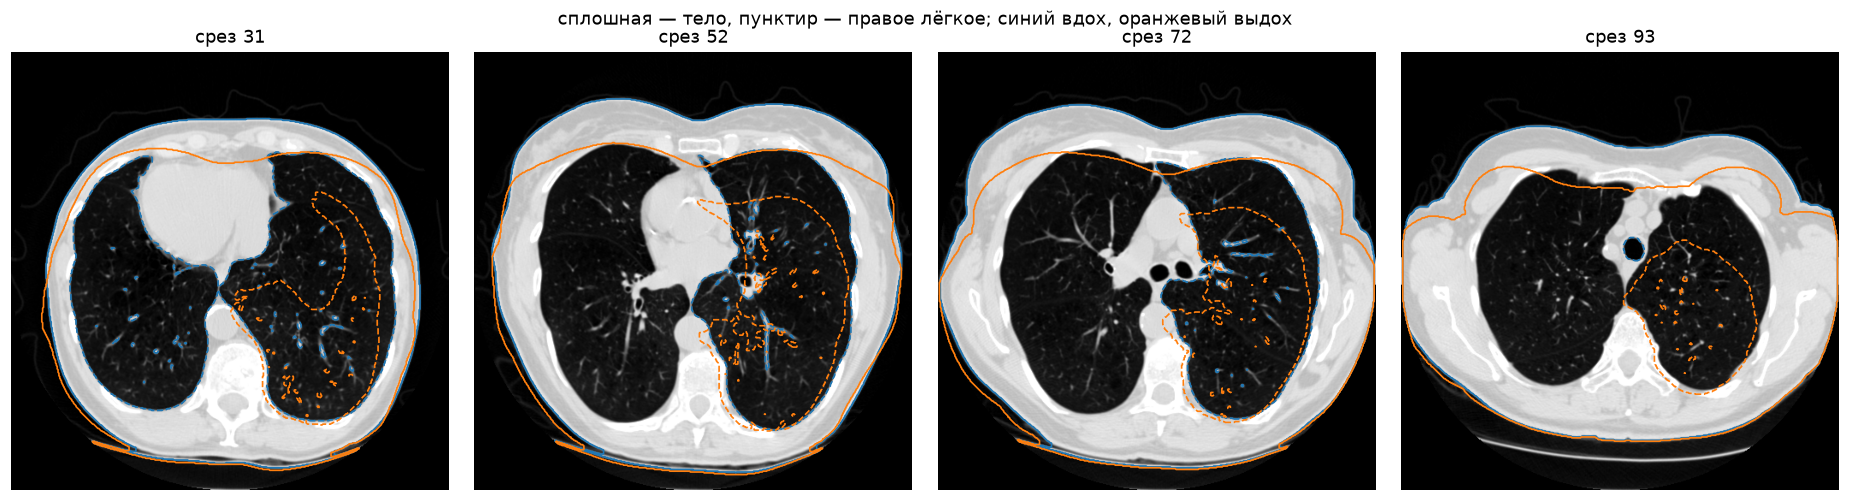

In [6]:
present = [k for k in range(volumes["iBHCT"].shape[2]) if lung_in[k] > 20]
levels = np.linspace(min(present), max(present), 6)[1:5].astype(int)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for a, index in zip(axes, levels, strict=True):
    a.imshow(volumes["iBHCT"][:, :, index].T, cmap="gray", vmin=-1000, vmax=200,
             origin="lower")
    for tag, colour in (("iBHCT", "tab:blue"), ("eBHCT", "tab:orange")):
        current = volumes[tag][:, :, index]
        mask = body_mask(current, MP)
        if mask is None:
            continue
        a.contour(mask.T, levels=[0.5], colors=colour, linewidths=1.1)
        lung = lung_mask(current, mask, Side.RIGHT, MP)
        if lung is not None:
            a.contour(lung.T, levels=[0.5], colors=colour, linewidths=1.1, linestyles="--")
    a.set_title(f"срез {index}")
    a.axis("off")
fig.suptitle("сплошная — тело, пунктир — правое лёгкое; синий вдох, оранжевый выдох")
fig.tight_layout()
plt.show()

## 6. Изменение наружной поверхности отдельно

Кожа и лёгкое меняются по-разному, и для двуслойной импедансной модели важна именно
разность: если кожа стоит, а лёгкое отходит, слой между ними толстеет.

Ниже — радиус тела и радиус лёгкого от общего центра, по углу, на одном уровне.

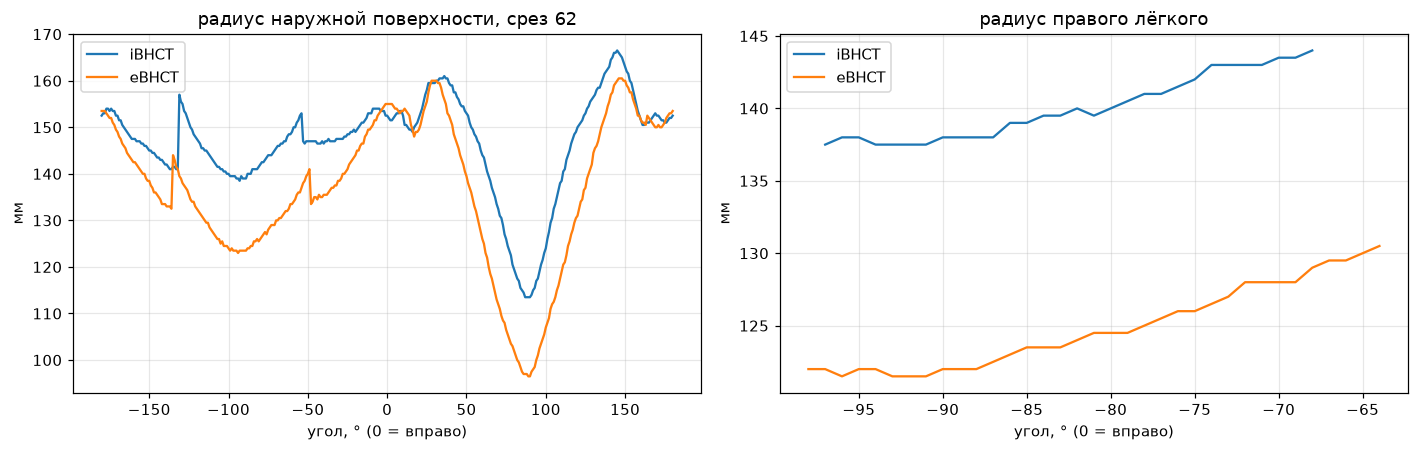

In [7]:
index = int(np.median(levels))
angles = np.radians(np.linspace(-180, 180, 361))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for tag, colour in (("iBHCT", "tab:blue"), ("eBHCT", "tab:orange")):
    current = volumes[tag][:, :, index]
    mask = body_mask(current, MP)
    lung = lung_mask(current, mask, Side.RIGHT, MP)
    centre = ndimage.center_of_mass(mask)
    radii = np.arange(1, 400) * 0.5
    body_r, lung_r = [], []
    for angle in angles:
        rr = np.clip(np.round(centre[0] + radii * np.cos(angle) / sx).astype(int),
                     0, mask.shape[0] - 1)
        cc = np.clip(np.round(centre[1] + radii * np.sin(angle) / sy).astype(int),
                     0, mask.shape[1] - 1)
        hit = np.flatnonzero(mask[rr, cc])
        body_r.append(radii[hit[-1]] if hit.size else np.nan)
        if lung is not None:
            hit = np.flatnonzero(lung[rr, cc])
            lung_r.append(radii[hit[-1]] if hit.size else np.nan)
        else:
            lung_r.append(np.nan)
    ax[0].plot(np.degrees(angles), body_r, color=colour, label=tag)
    ax[1].plot(np.degrees(angles), lung_r, color=colour, label=tag)
ax[0].set_title(f"радиус наружной поверхности, срез {index}")
ax[1].set_title("радиус правого лёгкого")
for a in ax:
    a.set_xlabel("угол, ° (0 = вправо)")
    a.set_ylabel("мм")
    a.legend()
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Что делать с результатом

Ноутбук считается пройденным, только если выполнено всё:

1. позвонок даёт пик в центре по лево-правой оси и смещён к краю по передне-задней;
2. сечение правого лёгкого меняется по срезам плавно, без скачков в десятки см²;
3. ни на одном срезе маска не выбирает оба лёгких сразу;
4. контуры тела двух фаз совпадают в пределах нескольких миллиметров.

Невыполнение пункта 2 или 3 означает, что выделение лёгкого не годится и любые толщины,
посчитанные на нём, недействительны — независимо от того, насколько устойчивыми они
выглядят при вариации параметров.

Невыполнение пункта 4 означает, что фазы не совмещены и разность содержит вклад позы.